# TPCC Comparison: dbfs vs PostgreSQL

This notebook compares two BenchBase TPCC runs collected under the same nominal settings and grouped under a shared comparison label:

- comparison label: `20260503`
- dbfs run label: `20260503-113027`
- PostgreSQL baseline label: `20260503-postgres-baseline-rerun`

The notebook reads results from `benchmarking/results/20260503/tpcc/dbfs` and `benchmarking/results/20260503/tpcc/postgres`, then loads summary, metrics, params, samples, results, raw traces, and per-procedure result windows to build side-by-side comparison tables and basic performance plots.

In [ ]:
from pathlib import Path
import json
import re

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

plt.style.use('ggplot')
pd.set_option('display.float_format', lambda value: f'{value:,.3f}')

comparison_root = Path(
    '/Users/yohasebe/Documents/dbfs/benchmarking/results/20260503/tpcc')

run_configs = {
    'dbfs': {
        'label': '20260503-113027',
        'display_name': 'dbfs',
        'result_dir': comparison_root / 'dbfs',
    },
    'postgres': {
        'label': '20260503-postgres-baseline-rerun',
        'display_name': 'PostgreSQL',
        'result_dir': comparison_root / 'postgres',
    },
}

configured_ratios = pd.Series(
    {
        'NewOrder': 45.0,
        'Payment': 43.0,
        'OrderStatus': 4.0,
        'Delivery': 4.0,
        'StockLevel': 4.0,
    },
    name='Configured Ratio (%)')

required_suffixes = {
    'summary': '.summary.json',
    'metrics': '.metrics.json',
    'params': '.params.json',
    'results': '.results.csv',
    'samples': '.samples.csv',
    'raw': '.raw.csv',
}

procedure_suffix = '.results.'

In [2]:
dbfs_terminal_log = '''
[INFO ] 2026-05-03 02:30:34,832 [main]  com.oltpbenchmark.DBWorkload main - ======================================================================
Benchmark:                       TPCC {com.oltpbenchmark.benchmarks.tpcc.TPCCBenchmark}
Configuration:                   /benchbase/benchbase-config/dbfs_tpcc_docker.xml
Type:                            POSTGRES
Driver:                          dev.yohaku.dbfs.jdbc.DbfsDriver
URL:                             jdbc:dbfs://dbfs:25432/benchbase
Isolation:                       TRANSACTION_SERIALIZABLE
Batch Size:                      128
DDL Path:                        null
Loader Threads:                  2
Session Setup File:              null
Scale Factor:                    1.0
Terminals:                       1
New Connection Per Txn:          false
Reconnect on Connection Failure: true
[INFO ] 2026-05-03 02:32:07,074 [main]  com.oltpbenchmark.ThreadBench runRateLimitedMultiPhase - PHASE START :: [Workload=TPCC] [Serial=false] [Time=60] [WarmupTime=0] [Rate=10000.0] [Arrival=REGULAR] [Ratios=[45.0, 43.0, 4.0, 4.0, 4.0]] [ActiveWorkers=1]
[INFO ] 2026-05-03 02:33:07,594 [main]  com.oltpbenchmark.DBWorkload runWorkload - Rate limited reqs/s: Results(state=EXIT, nanoSeconds=60198035111, measuredRequests=355) = 5.897202447644853 requests/sec (throughput), 5.9304261234062325 requests/sec (goodput)
Completed Transactions:
com.oltpbenchmark.benchmarks.tpcc.procedures.NewOrder/01                         [ 156] *****************************************************************************
com.oltpbenchmark.benchmarks.tpcc.procedures.Payment/02                          [ 161] ********************************************************************************
com.oltpbenchmark.benchmarks.tpcc.procedures.OrderStatus/03                      [   9] ****
com.oltpbenchmark.benchmarks.tpcc.procedures.Delivery/04                         [  18] ********
com.oltpbenchmark.benchmarks.tpcc.procedures.StockLevel/05                       [  13] ******
Aborted Transactions:
<EMPTY>
Unexpected SQL Errors:
<EMPTY>
'''

postgres_terminal_log = '''
[INFO ] 2026-05-03 02:38:47,990 [main]  com.oltpbenchmark.DBWorkload main - ======================================================================
Benchmark:                       TPCC {com.oltpbenchmark.benchmarks.tpcc.TPCCBenchmark}
Configuration:                   /benchbase/benchbase-config/postgres_tpcc_docker.xml
Type:                            POSTGRES
Driver:                          org.postgresql.Driver
URL:                             jdbc:postgresql://postgres:5432/benchbase?sslmode=disable&ApplicationName=tpcc&reWriteBatchedInserts=true
Isolation:                       TRANSACTION_SERIALIZABLE
Batch Size:                      128
DDL Path:                        null
Loader Threads:                  2
Session Setup File:              null
Scale Factor:                    1.0
Terminals:                       1
New Connection Per Txn:          false
Reconnect on Connection Failure: true
[INFO ] 2026-05-03 02:39:16,112 [main]  com.oltpbenchmark.ThreadBench runRateLimitedMultiPhase - PHASE START :: [Workload=TPCC] [Serial=false] [Time=60] [WarmupTime=0] [Rate=10000.0] [Arrival=REGULAR] [Ratios=[45.0, 43.0, 4.0, 4.0, 4.0]] [ActiveWorkers=1]
[INFO ] 2026-05-03 02:40:17,594 [main]  com.oltpbenchmark.DBWorkload runWorkload - Rate limited reqs/s: Results(state=EXIT, nanoSeconds=60110132319, measuredRequests=19291) = 320.9275916683081 requests/sec (throughput), 319.5467928445836 requests/sec (goodput)
Completed Transactions:
com.oltpbenchmark.benchmarks.tpcc.procedures.NewOrder/01                         [8668] ********************************************************************************
com.oltpbenchmark.benchmarks.tpcc.procedures.Payment/02                          [8210] ***************************************************************************
com.oltpbenchmark.benchmarks.tpcc.procedures.OrderStatus/03                      [ 804] *******
com.oltpbenchmark.benchmarks.tpcc.procedures.Delivery/04                         [ 764] *******
com.oltpbenchmark.benchmarks.tpcc.procedures.StockLevel/05                       [ 762] *******
Aborted Transactions:
com.oltpbenchmark.benchmarks.tpcc.procedures.NewOrder/01                         [  84] ********************************************************************************
Unexpected SQL Errors:
<EMPTY>
'''

run_configs['dbfs']['terminal_log'] = dbfs_terminal_log
run_configs['postgres']['terminal_log'] = postgres_terminal_log

field_patterns = {
    'workload': re.compile(r'Benchmark:\s+(\w+)'),
    'dbms_type': re.compile(r'Type:\s+(\w+)'),
    'driver': re.compile(r'Driver:\s+(.+)'),
    'url': re.compile(r'URL:\s+(.+)'),
    'isolation': re.compile(r'Isolation:\s+(\S+)'),
    'loader_threads': re.compile(r'Loader Threads:\s+(\d+)'),
    'scale_factor': re.compile(r'Scale Factor:\s+([\d.]+)'),
    'terminals': re.compile(r'Terminals:\s+(\d+)'),
}
phase_pattern = re.compile(
    r'PHASE START :: .*\[Time=(\d+)\] \[WarmupTime=(\d+)\] \[Rate=([\d.]+)\].*\[Ratios=\[([^\]]+)\]\]'
)
rate_pattern = re.compile(
    r'measuredRequests=(\d+)\) = ([\d.]+) requests/sec \(throughput\), ([\d.]+) requests/sec \(goodput\)'
)


def parse_terminal_log(log_text):
    parsed = {}
    for key, pattern in field_patterns.items():
        match = pattern.search(log_text)
        parsed[key] = match.group(1).strip() if match else None

    phase_match = phase_pattern.search(log_text)
    if phase_match:
        parsed['phase_time_seconds'] = int(phase_match.group(1))
        parsed['warmup_time_seconds'] = int(phase_match.group(2))
        parsed['target_rate'] = float(phase_match.group(3))
        parsed['configured_ratio_list'] = [
            float(value.strip()) for value in phase_match.group(4).split(',')
        ]

    rate_match = rate_pattern.search(log_text)
    if rate_match:
        parsed['terminal_measured_requests'] = int(rate_match.group(1))
        parsed['terminal_throughput'] = float(rate_match.group(2))
        parsed['terminal_goodput'] = float(rate_match.group(3))

    return parsed


parsed_configs = pd.DataFrame([{
    'engine': engine,
    **parse_terminal_log(config['terminal_log'])
} for engine, config in run_configs.items()])
parsed_configs

,engine,workload,dbms_type,driver,url,isolation,loader_threads,scale_factor,terminals,phase_time_seconds,warmup_time_seconds,target_rate,configured_ratio_list,terminal_measured_requests,terminal_throughput,terminal_goodput
0,dbfs,TPCC,POSTGRES,dev.yohaku.dbfs.jdbc.DbfsDriver,jdbc:dbfs://dbfs:25432/benchbase,TRANSACTION_SERIALIZABLE,2,1.0,1,60,0,"10,000.000","[45.0, 43.0, 4.0, 4.0, 4.0]",355,5.897,5.930
1,postgres,TPCC,POSTGRES,org.postgresql.Driver,jdbc:postgresql://postgres:5432/benchbase?sslm...,TRANSACTION_SERIALIZABLE,2,1.0,1,60,0,"10,000.000","[45.0, 43.0, 4.0, 4.0, 4.0]",19291,320.928,319.547


In [3]:
def find_artifact(result_dir, suffix):
    matches = sorted(result_dir.glob(f'*{suffix}'))
    if not matches:
        raise FileNotFoundError(
            f'No artifact ending with {suffix} under {result_dir}')
    return matches[0]


def load_run_artifacts(config):
    result_dir = config['result_dir']
    artifacts = {
        name: find_artifact(result_dir, suffix)
        for name, suffix in required_suffixes.items()
    }
    procedure_paths = sorted(result_dir.glob('*.results.*.csv'))

    with artifacts['summary'].open() as handle:
        summary = json.load(handle)
    with artifacts['metrics'].open() as handle:
        metrics = json.load(handle)
    with artifacts['params'].open() as handle:
        params = json.load(handle)

    results_df = pd.read_csv(artifacts['results'])
    samples_df = pd.read_csv(artifacts['samples'])
    raw_df = pd.read_csv(artifacts['raw'])
    procedure_dfs = {
        path.stem.split('.results.', 1)[1]: pd.read_csv(path)
        for path in procedure_paths
    }

    return {
        'artifacts': artifacts,
        'summary': summary,
        'metrics': metrics,
        'params': params,
        'results_df': results_df,
        'samples_df': samples_df,
        'raw_df': raw_df,
        'procedure_dfs': procedure_dfs,
    }


runs = {}
validation_rows = []
for engine, config in run_configs.items():
    run_data = load_run_artifacts(config)
    runs[engine] = {**config, **run_data}
    validation_rows.extend([
        {
            'engine': engine,
            'artifact': 'results.csv',
            'rows': len(run_data['results_df']),
            'columns': ', '.join(run_data['results_df'].columns),
        },
        {
            'engine': engine,
            'artifact': 'samples.csv',
            'rows': len(run_data['samples_df']),
            'columns': ', '.join(run_data['samples_df'].columns),
        },
        {
            'engine': engine,
            'artifact': 'raw.csv',
            'rows': len(run_data['raw_df']),
            'columns': ', '.join(run_data['raw_df'].columns),
        },
        {
            'engine': engine,
            'artifact': 'procedure_results',
            'rows': len(run_data['procedure_dfs']),
            'columns': ', '.join(sorted(run_data['procedure_dfs'].keys())),
        },
    ])

validation_df = pd.DataFrame(validation_rows)
validation_df

,engine,artifact,rows,columns
0,dbfs,results.csv,12,"Time (seconds), Throughput (requests/second), ..."
1,dbfs,samples.csv,59,"Time (seconds), Requests, Throughput (requests..."
2,dbfs,raw.csv,355,"Transaction Type Index, Transaction Name, Star..."
3,dbfs,procedure_results,5,"Delivery, NewOrder, OrderStatus, Payment, Stoc..."
4,postgres,results.csv,12,"Time (seconds), Throughput (requests/second), ..."
5,postgres,samples.csv,60,"Time (seconds), Requests, Throughput (requests..."
6,postgres,raw.csv,19291,"Transaction Type Index, Transaction Name, Star..."
7,postgres,procedure_results,5,"Delivery, NewOrder, OrderStatus, Payment, Stoc..."


In [4]:
summary_rows = []
for engine, run in runs.items():
    parsed = parse_terminal_log(run['terminal_log'])
    summary = run['summary']
    latency = summary['Latency Distribution']

    summary_rows.append({
        'Engine':
        run['display_name'],
        'Run Label':
        run['label'],
        'Measured Requests':
        summary['Measured Requests'],
        'Elapsed Seconds':
        summary['Elapsed Time (nanoseconds)'] / 1_000_000_000,
        'Throughput (req/s)':
        summary['Throughput (requests/second)'],
        'Goodput (req/s)':
        summary['Goodput (requests/second)'],
        'Requests per Minute':
        summary['Throughput (requests/second)'] * 60,
        'Throughput - Goodput Gap':
        summary['Throughput (requests/second)'] -
        summary['Goodput (requests/second)'],
        'Average Latency (ms)':
        latency['Average Latency (microseconds)'] / 1000,
        'Median Latency (ms)':
        latency['Median Latency (microseconds)'] / 1000,
        'P95 Latency (ms)':
        latency['95th Percentile Latency (microseconds)'] / 1000,
        'P99 Latency (ms)':
        latency['99th Percentile Latency (microseconds)'] / 1000,
        'Max Latency (ms)':
        latency['Maximum Latency (microseconds)'] / 1000,
        'Terminal Throughput (req/s)':
        parsed.get('terminal_throughput'),
        'Terminal Goodput (req/s)':
        parsed.get('terminal_goodput'),
    })

summary_comparison_df = pd.DataFrame(summary_rows).set_index('Engine')
summary_comparison_df

,Run Label,Measured Requests,Elapsed Seconds,Throughput (req/s),Goodput (req/s),Requests per Minute,Throughput - Goodput Gap,Average Latency (ms),Median Latency (ms),P95 Latency (ms),P99 Latency (ms),Max Latency (ms),Terminal Throughput (req/s),Terminal Goodput (req/s)
Engine,,,,,,,,,,,,,,
dbfs,20260503-113027,355,60.198,5.897,5.930,353.832,-0.033,164.803,8.640,"1,449.110","2,138.680","2,592.010",5.897,5.930
PostgreSQL,20260503-postgres-baseline-rerun,19291,60.110,320.928,319.547,"19,255.656",1.381,3.066,1.710,7.968,18.630,"2,233.845",320.928,319.547


In [5]:
transaction_names = [
    'NewOrder', 'Payment', 'OrderStatus', 'Delivery', 'StockLevel'
]
transaction_pattern = re.compile(r'procedures\.(\w+)/\d+\s+\[\s*(\d+)\]')


def extract_histogram_counts(log_text, section_name):
    section_pattern = re.compile(
        rf'{section_name}:\n(.*?)(?:\n\w[\w ]+:|\Z)',
        re.DOTALL,
    )
    match = section_pattern.search(log_text)
    if not match:
        return {name: 0 for name in transaction_names}

    block = match.group(1).strip()
    if '<EMPTY>' in block:
        return {name: 0 for name in transaction_names}

    counts = {name: 0 for name in transaction_names}
    for name, count in transaction_pattern.findall(block):
        counts[name] = int(count)
    return counts


mix_rows = []
for engine, run in runs.items():
    completed = extract_histogram_counts(run['terminal_log'],
                                         'Completed Transactions')
    aborted = extract_histogram_counts(run['terminal_log'],
                                       'Aborted Transactions')
    completed_total = sum(completed.values())
    aborted_total = sum(aborted.values())

    for name in transaction_names:
        mix_rows.append({
            'Engine':
            run['display_name'],
            'Transaction':
            name,
            'Completed':
            completed[name],
            'Aborted':
            aborted[name],
            'Observed Mix (%)': (completed[name] / completed_total *
                                 100) if completed_total else 0.0,
            'Abort Rate (%)':
            (aborted[name] / (completed[name] + aborted[name]) * 100) if
            (completed[name] + aborted[name]) else 0.0,
        })

transaction_mix_df = pd.DataFrame(mix_rows)
transaction_mix_df

,Engine,Transaction,Completed,Aborted,Observed Mix (%),Abort Rate (%)
0,dbfs,NewOrder,156,0,43.697,0.000
1,dbfs,Payment,161,0,45.098,0.000
2,dbfs,OrderStatus,9,0,2.521,0.000
3,dbfs,Delivery,18,0,5.042,0.000
4,dbfs,StockLevel,13,0,3.641,0.000
5,PostgreSQL,NewOrder,8668,84,45.127,0.960
6,PostgreSQL,Payment,8210,0,42.743,0.000
7,PostgreSQL,OrderStatus,804,0,4.186,0.000
8,PostgreSQL,Delivery,764,0,3.978,0.000
9,PostgreSQL,StockLevel,762,0,3.967,0.000


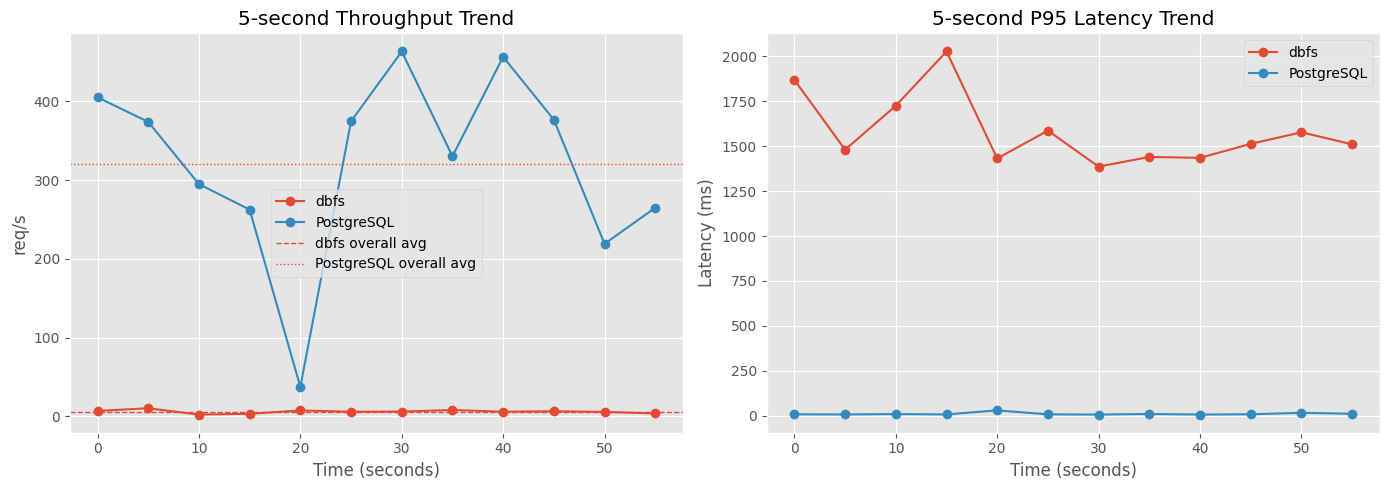

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for engine, run in runs.items():
    results_df = run['results_df']
    label = run['display_name']
    axes[0].plot(
        results_df['Time (seconds)'],
        results_df['Throughput (requests/second)'],
        marker='o',
        label=label,
    )
    axes[1].plot(
        results_df['Time (seconds)'],
        results_df['95th Percentile Latency (millisecond)'],
        marker='o',
        label=label,
    )

axes[0].axhline(
    summary_comparison_df.loc['dbfs', 'Throughput (req/s)'],
    linestyle='--',
    linewidth=1,
    label='dbfs overall avg',
)
axes[0].axhline(
    summary_comparison_df.loc['PostgreSQL', 'Throughput (req/s)'],
    linestyle=':',
    linewidth=1,
    label='PostgreSQL overall avg',
)
axes[0].set_title('5-second Throughput Trend')
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('req/s')
axes[0].legend()

axes[1].set_title('5-second P95 Latency Trend')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Latency (ms)')
axes[1].legend()

fig.tight_layout()
plt.show()

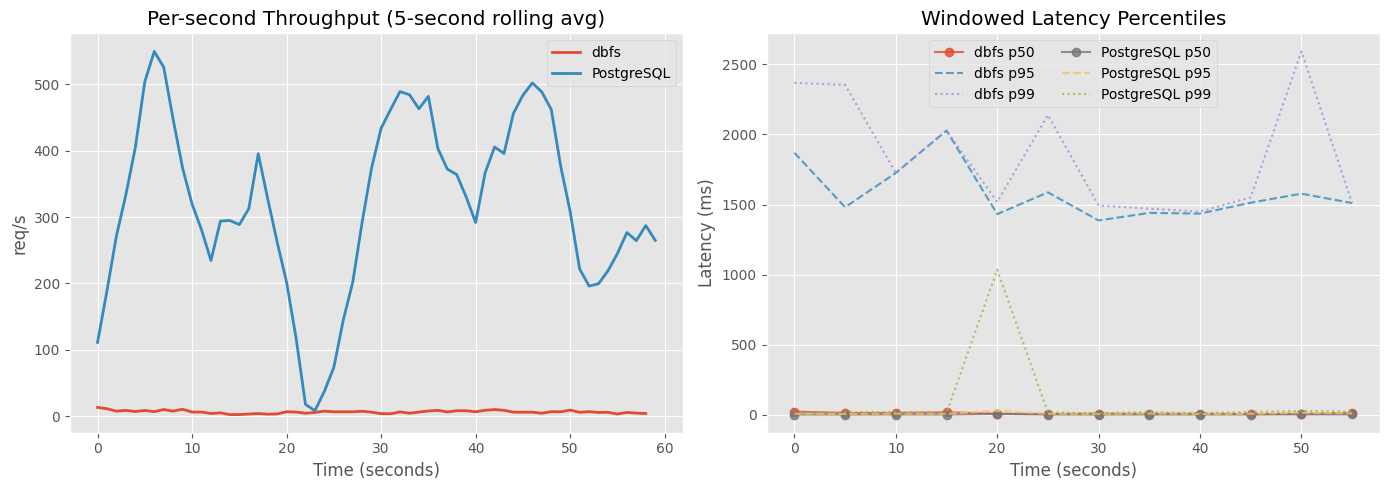

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for engine, run in runs.items():
    samples_df = run['samples_df'].copy()
    results_df = run['results_df']
    label = run['display_name']
    samples_df['Throughput Rolling'] = samples_df[
        'Throughput (requests/second)'].rolling(5, min_periods=1).mean()

    axes[0].plot(
        samples_df['Time (seconds)'],
        samples_df['Throughput Rolling'],
        linewidth=2,
        label=label,
    )
    axes[1].plot(
        results_df['Time (seconds)'],
        results_df['Median Latency (millisecond)'],
        marker='o',
        alpha=0.8,
        label=f'{label} p50',
    )
    axes[1].plot(
        results_df['Time (seconds)'],
        results_df['95th Percentile Latency (millisecond)'],
        linestyle='--',
        alpha=0.8,
        label=f'{label} p95',
    )
    axes[1].plot(
        results_df['Time (seconds)'],
        results_df['99th Percentile Latency (millisecond)'],
        linestyle=':',
        alpha=0.8,
        label=f'{label} p99',
    )

axes[0].set_title('Per-second Throughput (5-second rolling avg)')
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('req/s')
axes[0].legend()

axes[1].set_title('Windowed Latency Percentiles')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Latency (ms)')
axes[1].legend(ncol=2)

fig.tight_layout()
plt.show()

,Engine,Procedure,Avg Throughput (req/s),Avg Latency (ms),Avg P95 Latency (ms)
5,PostgreSQL,Delivery,12.733,16.842,104.843
0,dbfs,Delivery,0.300,652.003,786.651
6,PostgreSQL,NewOrder,145.867,6.407,10.104
1,dbfs,NewOrder,2.583,215.219,"1,562.245"
7,PostgreSQL,OrderStatus,13.400,2.312,6.989
2,dbfs,OrderStatus,0.150,102.270,106.548
8,PostgreSQL,Payment,136.817,1.861,6.553
3,dbfs,Payment,2.667,44.157,362.389
9,PostgreSQL,StockLevel,12.700,5.516,16.545
4,dbfs,StockLevel,0.217,248.779,354.107


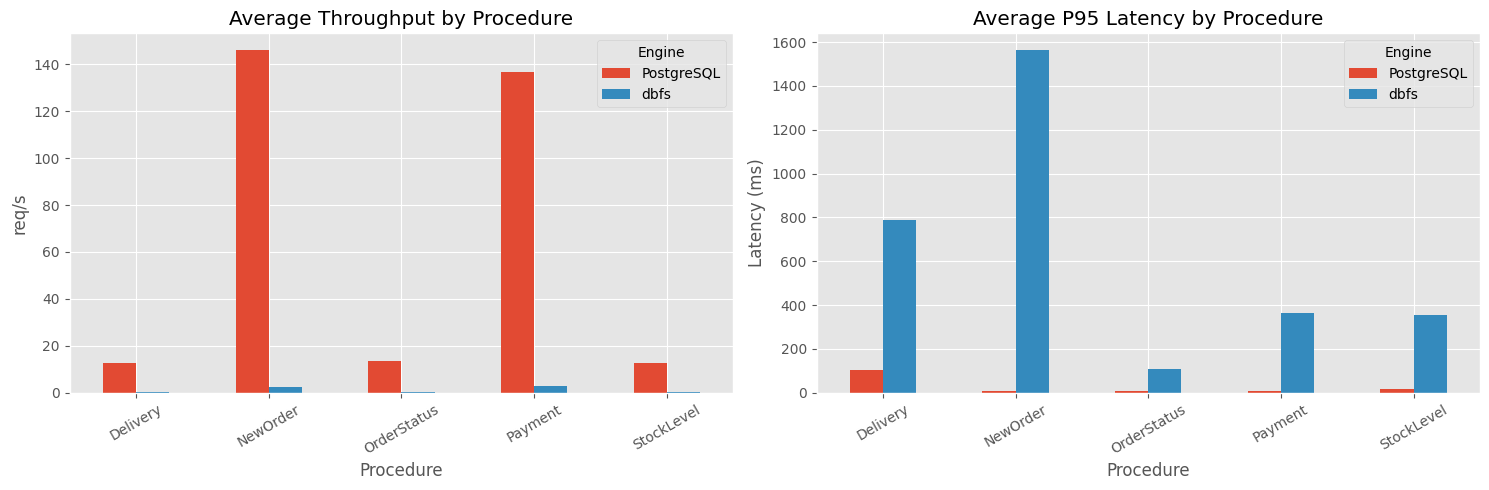

In [8]:
procedure_rows = []
for engine, run in runs.items():
    for procedure_name, procedure_df in run['procedure_dfs'].items():
        procedure_rows.append({
            'Engine':
            run['display_name'],
            'Procedure':
            procedure_name,
            'Avg Throughput (req/s)':
            procedure_df['Throughput (requests/second)'].mean(),
            'Avg Latency (ms)':
            procedure_df['Average Latency (millisecond)'].mean(),
            'Avg P95 Latency (ms)':
            procedure_df['95th Percentile Latency (millisecond)'].mean(),
        })

procedure_comparison_df = pd.DataFrame(procedure_rows).sort_values(
    ['Procedure', 'Engine'])
display(procedure_comparison_df)

procedure_throughput = procedure_comparison_df.pivot(
    index='Procedure', columns='Engine', values='Avg Throughput (req/s)')
procedure_p95 = procedure_comparison_df.pivot(index='Procedure',
                                              columns='Engine',
                                              values='Avg P95 Latency (ms)')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
procedure_throughput.plot(kind='bar', ax=axes[0])
axes[0].set_title('Average Throughput by Procedure')
axes[0].set_ylabel('req/s')
axes[0].tick_params(axis='x', rotation=30)

procedure_p95.plot(kind='bar', ax=axes[1])
axes[1].set_title('Average P95 Latency by Procedure')
axes[1].set_ylabel('Latency (ms)')
axes[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()

In [11]:
mix_comparison_rows = []
for engine in transaction_mix_df['Engine'].unique():
    engine_mix = transaction_mix_df[transaction_mix_df['Engine'] ==
                                    engine].set_index('Transaction')
    for transaction_name, configured_ratio in configured_ratios.items():
        observed_ratio = engine_mix.loc[transaction_name, 'Observed Mix (%)']
        mix_comparison_rows.append({
            'Engine':
            engine,
            'Transaction':
            transaction_name,
            'Configured Ratio (%)':
            configured_ratio,
            'Observed Ratio (%)':
            observed_ratio,
            'Absolute Error (pp)':
            abs(observed_ratio - configured_ratio),
        })

mix_comparison_df = pd.DataFrame(mix_comparison_rows)
display(mix_comparison_df)

report_rows = []
for engine, run in runs.items():
    parsed = parse_terminal_log(run['terminal_log'])
    completed_total = transaction_mix_df.loc[transaction_mix_df['Engine'] ==
                                             run['display_name'],
                                             'Completed'].sum()
    aborted_total = transaction_mix_df.loc[
        transaction_mix_df['Engine'] == run['display_name'], 'Aborted'].sum()

    report_rows.append({
        'run_label':
        run['label'],
        'engine':
        run['display_name'],
        'dbms_type':
        parsed['dbms_type'],
        'workload':
        parsed['workload'],
        'scale_factor':
        float(parsed['scale_factor']),
        'terminals':
        int(parsed['terminals']),
        'duration_seconds':
        run['summary']['Elapsed Time (nanoseconds)'] / 1_000_000_000,
        'measured_requests':
        run['summary']['Measured Requests'],
        'throughput_req_per_s':
        run['summary']['Throughput (requests/second)'],
        'goodput_req_per_s':
        run['summary']['Goodput (requests/second)'],
        'completed_transactions':
        int(completed_total),
        'aborted_transactions':
        int(aborted_total),
        'abort_percentage':
        (aborted_total / (completed_total + aborted_total) * 100) if
        (completed_total + aborted_total) else 0.0,
    })

report_df = pd.DataFrame(report_rows)
display(report_df)

,Engine,Transaction,Configured Ratio (%),Observed Ratio (%),Absolute Error (pp)
0,dbfs,NewOrder,45.000,43.697,1.303
1,dbfs,Payment,43.000,45.098,2.098
2,dbfs,OrderStatus,4.000,2.521,1.479
3,dbfs,Delivery,4.000,5.042,1.042
4,dbfs,StockLevel,4.000,3.641,0.359
5,PostgreSQL,NewOrder,45.000,45.127,0.127
6,PostgreSQL,Payment,43.000,42.743,0.257
7,PostgreSQL,OrderStatus,4.000,4.186,0.186
8,PostgreSQL,Delivery,4.000,3.978,0.022
9,PostgreSQL,StockLevel,4.000,3.967,0.033


,run_label,engine,dbms_type,workload,scale_factor,terminals,duration_seconds,measured_requests,throughput_req_per_s,goodput_req_per_s,completed_transactions,aborted_transactions,abort_percentage
0,20260503-113027,dbfs,POSTGRES,TPCC,1.000,1,60.198,355,5.897,5.930,357,0,0.000
1,20260503-postgres-baseline-rerun,PostgreSQL,POSTGRES,TPCC,1.000,1,60.110,19291,320.928,319.547,19208,84,0.435


## Comparison Notes

Conclusion template:

- PostgreSQL shows a large throughput advantage over dbfs under the same TPCC configuration.
- dbfs completed the same workload shape without unexpected SQL errors, which means the current SQL support is sufficient for this TPCC slice.
- The main next step is performance-oriented investigation: loader behavior, per-procedure latency spikes, and the gap between dbfs and PostgreSQL throughput.
- The exported CSV files in `benchmarking/notebooks/exports/` can be reused by later notebooks for larger cross-run comparisons.